In [1]:
import os

path="./dogs-vs-cats/train/"
os.listdir(path)

['cat', 'dog']

In [2]:
full_names=os.listdir(path)
labels=[each.split('.')[0]for each in full_names]
file_id=[each.split('.')[1] for each in full_names]

IndexError: list index out of range

In [3]:
#데이터의 특성(크기, 이미지 특징 등)을 확인하기 위해서 하는 거

import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline

sample=random.choice(full_names)
image=mpimg.imread(path+sample)
plt.imshow(image)
plt.show()

IsADirectoryError: [Errno 21] Is a directory: './dogs-vs-cats/train/dog'

In [ ]:
sample=random.choice(full_names)
image=mpimg.imread(path+sample)
image.shape


#크기가 고정되어 있지 않음....

(375, 499, 3)

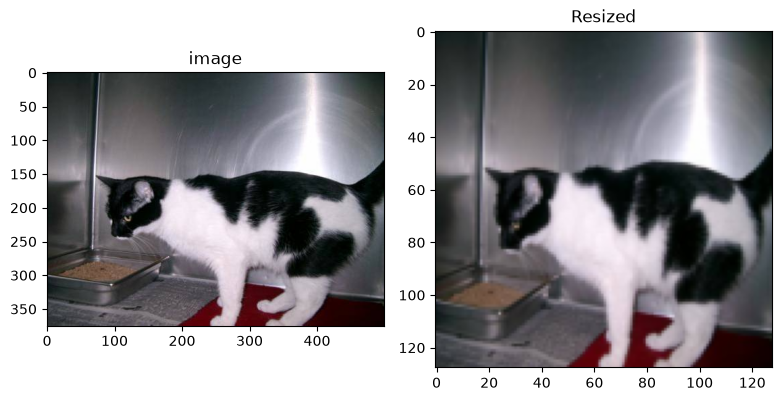

In [15]:
from skimage.transform import resize
resized = resize(image, (128, 128, 3))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
ax = axes.ravel()

ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title("image")
ax[1].imshow(resized, cmap=plt.cm.gray)
ax[1].set_title("Resized")

fig.tight_layout()
plt.show()

In [ ]:
from tqdm.notebook import tqdm
import numpy as np

images = []
bar_total = tqdm(full_names)
for file in bar_total:
    image = mpimg.imread(path + file)
    images.append(resize(image, (128, 128, 3)))

images = np.array(images)

  0%|          | 0/25000 [00:00<?, ?it/s]

In [21]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
encoder.fit(labels) #어떤 라벨이 있는지 확인하고 알파벳순으로 라벨 부여
labels_encoded=encoder.transform(labels) #라벨 변환
labels_encoded[:3],encoder.classes_



(array([1, 1, 0]), array(['cat', 'dog'], dtype='<U3'))

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = \
      train_test_split(images, labels_encoded, test_size=0.2,
                       random_state=13, stratify=labels_encoded)

X_train.shape, X_test.shape

((20000, 32, 32, 3), (5000, 32, 32, 3))

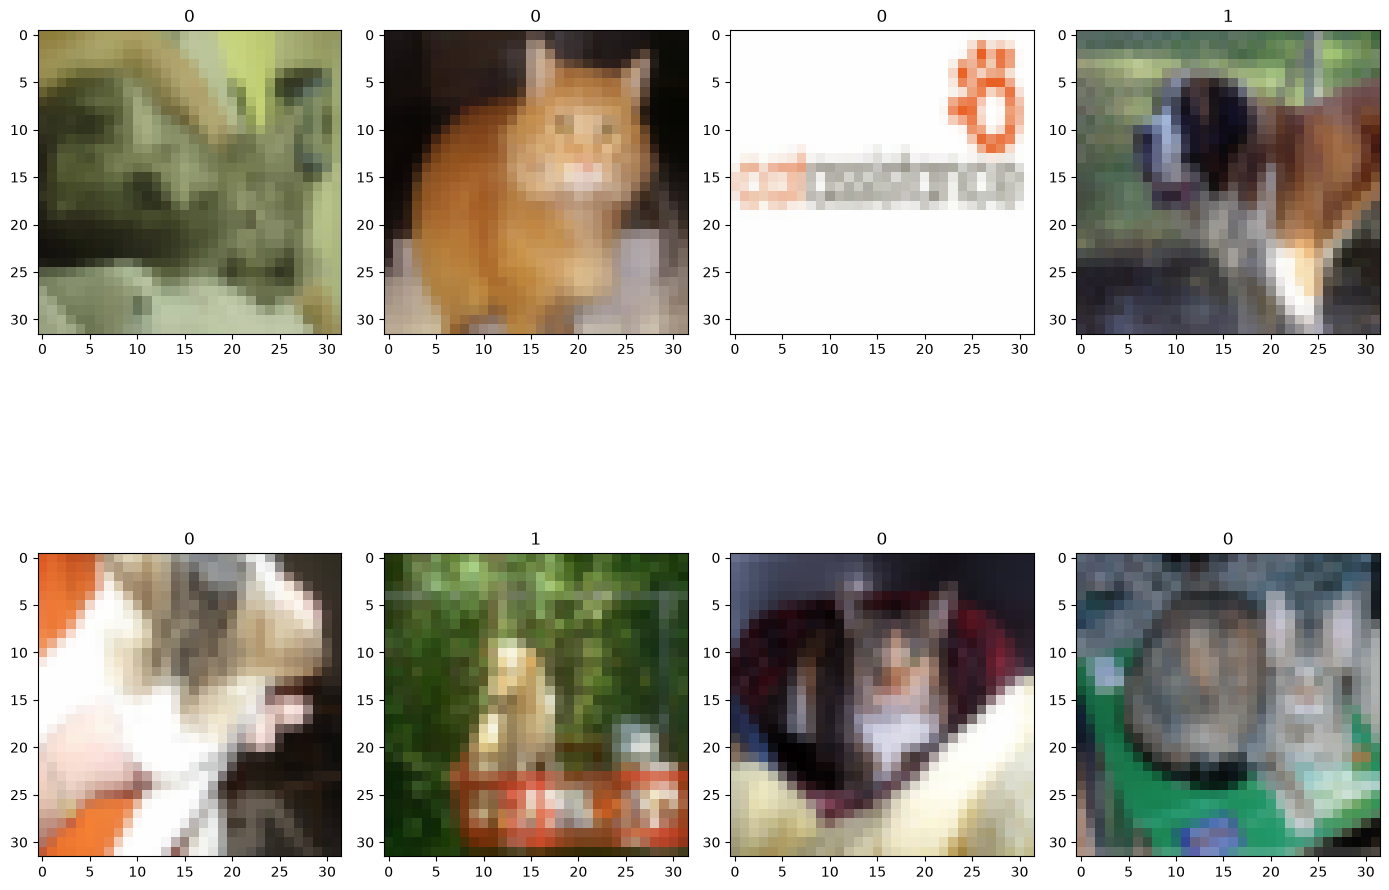

In [23]:
samples=random.choices(population=range(0,20000),k=8)

plt.figure(figsize=(14, 12))
for idx, n in enumerate(samples):
    plt.subplot(2, 4, idx+1)
    plt.imshow(X_train[n], cmap='Greys',
               interpolation='nearest')
    plt.title(y_train[n])

plt.tight_layout()
plt.show()

In [24]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, kernel_size=(3,3), activation='relu',
                  input_shape=(32, 32, 3)),
    layers.MaxPooling2D(pool_size=(2,2), strides=(2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.25),
    layers.Dense(2, activation='softmax')
])

I0000 00:00:1783582237.869789   55483 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/ane/tensorflow/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1783582240.541958   55483 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6090 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [25]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       295,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 352,770 (1.35 MB)

 Trainable params: 352,770 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model.compile(optimizer='adam',
              loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy'])

import time

start_time = time.time()
hist = model.fit(X_train, y_train,
                 epochs=10, verbose=1,
                 validation_data = (X_test, y_test))
print("fit time : ", time.time() - start_time)

Epoch 1/10


W0000 00:00:1783582532.487426   55483 cpu_allocator_impl.cc:82] Allocation of 245760000 exceeds 10% of free system memory.
I0000 00:00:1783582534.040236   57904 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_36077__.43


625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7894 - loss: 0.4450 - val_accuracy: 0.8062 - val_loss: 0.4190
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7973 - loss: 0.4337 - val_accuracy: 0.8152 - val_loss: 0.4049
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8012 - loss: 0.4269 - val_accuracy: 0.8112 - val_loss: 0.4105
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8094 - loss: 0.4137 - val_accuracy: 0.8130 - val_loss: 0.3982
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8121 - loss: 0.4080 - val_accuracy: 0.8144 - val_loss: 0.4090
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8102 - loss: 0.4018 - val_accuracy: 0.8228 - val_loss: 0.3976
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8159 - loss: 0.3984 - val_accuracy: 0.8340 - val_loss: 0.3798
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8247 - loss: 0.3886 - val_accuracy: 0.8268 - val_

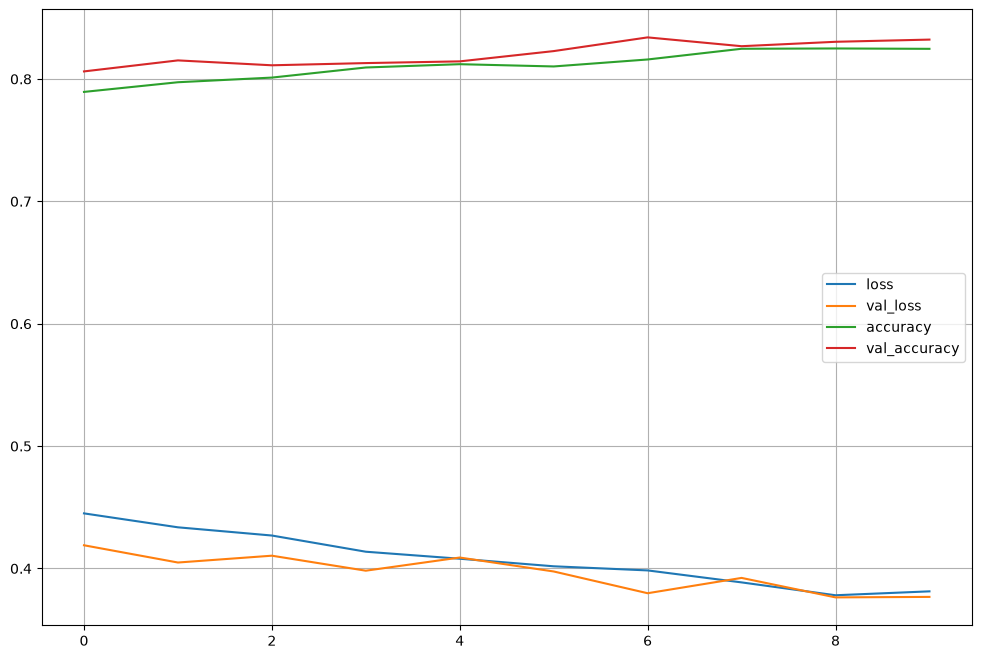

In [28]:
plot_target = ['loss', 'val_loss', 'accuracy', 'val_accuracy']
plt.figure(figsize = (12,8))

for each in plot_target:
    plt.plot(hist.history[each], label=each)

plt.legend()
plt.grid()
plt.show()

In [33]:
# 128X128이미지로 학습하기 위한 IMAGE GENERATOR사용


import os
import shutil

classes=['cat','dog']

for class_name in classes:
    class_path = os.path.join(path, class_name)
    os.makedirs(class_path, exist_ok=True)
    for file in full_names:
        if class_name in file:
            shutil.move(os.path.join(path, file), os.path.join(class_path, file))

In [34]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    validation_split=0.2
)

In [35]:
batch_size = 32

train_generator = datagen.flow_from_directory(
    path, 
    target_size=(128, 128),
    batch_size=batch_size,
    class_mode='binary',
    subset='training' # 훈련 데이터셋으로 설정
)

Found 20000 images belonging to 2 classes.


In [36]:
validation_generator = datagen.flow_from_directory(
    path,   # "/content/train/"
    target_size=(128, 128),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation' # 검증 데이터셋으로 설정
)

Found 5000 images belonging to 2 classes.


In [37]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, kernel_size=(3,3), activation='relu',
                  input_shape=(128, 128, 3)),
    layers.MaxPooling2D(pool_size=(2,2), strides=(2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.25),
    layers.Dense(2, activation='softmax')
])

/home/ane/tensorflow/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
model.compile(optimizer='adam',
              loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy'])

model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=1,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size
)

I0000 00:00:1783583350.123365   55483 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1783583351.477910   57903 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_70134__.43


625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 43ms/step - accuracy: 0.6351 - loss: 0.6385 - val_accuracy: 0.6945 - val_loss: 0.5906
